In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau)
from sklearn.metrics import classification_report, confusion_matrix

print(f"Tensor Version : {tf.__version__}")
print(f"GPU Available  : {tf.config.list_physical_devices('GPU')}")

Tensor Version : 2.19.0
GPU Available  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## **Load Dataset**

In [2]:
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw)= keras.datasets.cifar10.load_data()

CLASS_NAMES=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

NUM_CLASSES=10

print(f"Train Images Shape : {x_train_raw.shape}")
print(f"Test Images Shape : {x_test_raw.shape}")
print(f"Train lables Shape : {y_train_raw.shape}")
print(f"Train Images Shape : [{x_train_raw.min()}, {x_train_raw.max()}]")



170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train Images Shape : (50000, 32, 32, 3)
Test Images Shape : (10000, 32, 32, 3)
Train lables Shape : (50000, 1)
Train Images Shape : [0, 255]


## **Exploratory Data Analysis**

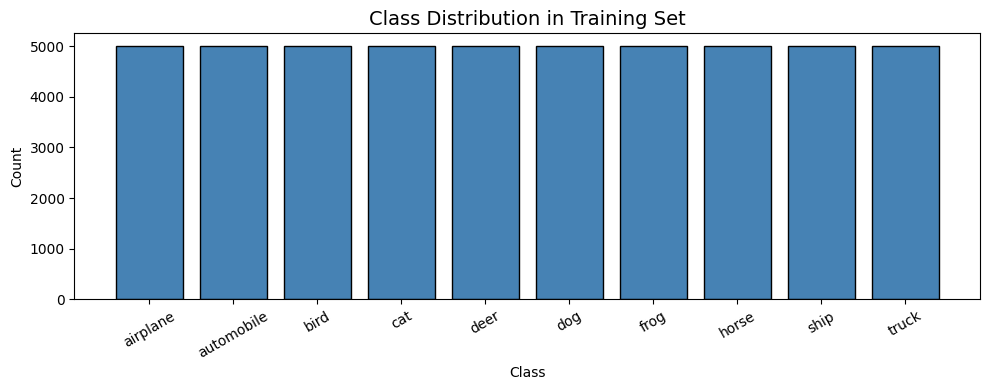

In [8]:
unique,counts=np.unique(y_train_raw, return_counts=True)
plt.figure(figsize=(10,4))
plt.bar([CLASS_NAMES[i] for i in unique],counts, color="steelblue",edgecolor="black")
plt.title("Class Distribution in Training Set", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

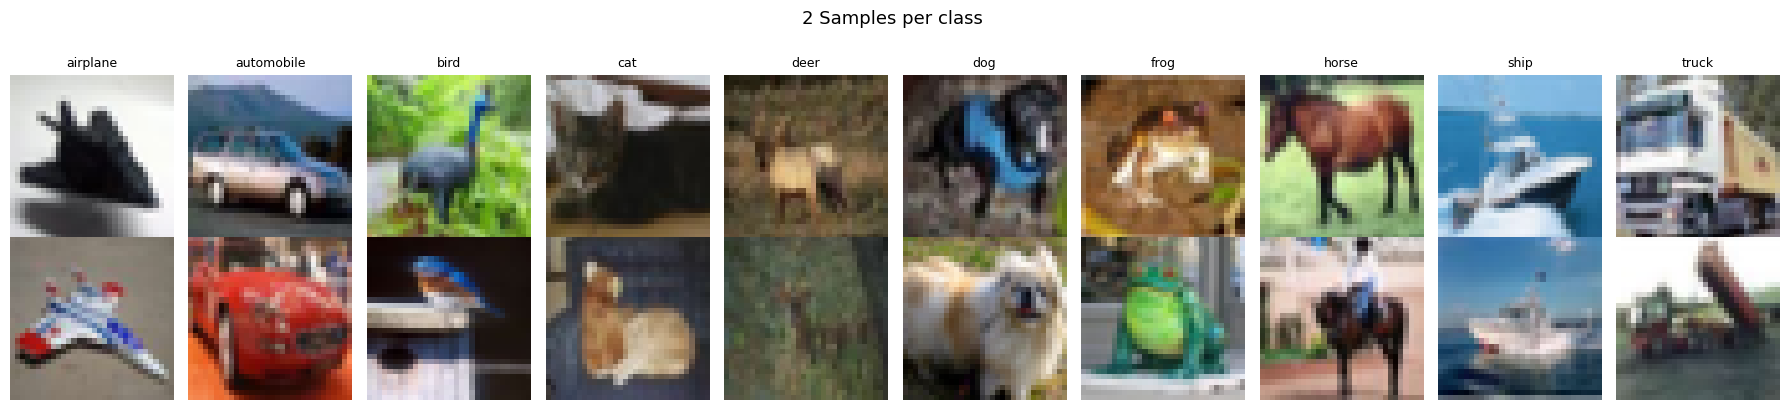

In [10]:
fig, axes=plt.subplots(2,10, figsize=(18,4))
for cls_idx in range(10):
    idxs=np.where(y_train_raw.flatten()==cls_idx)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row][cls_idx].imshow(x_train_raw[idx])
        axes[row][cls_idx].axis('off')
        if row==0:
            axes[row][cls_idx].set_title(CLASS_NAMES[cls_idx],fontsize=9)
plt.suptitle('2 Samples per class ',fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

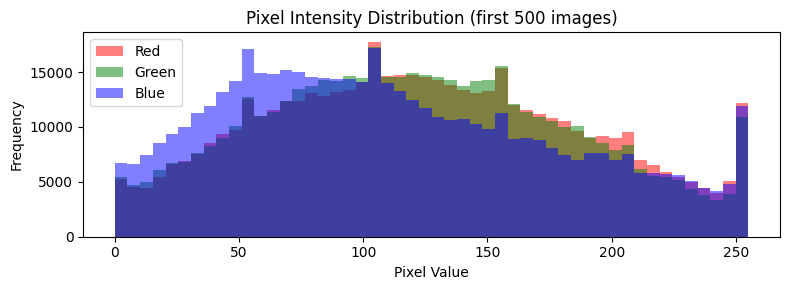

In [11]:
plt.figure(figsize=(8, 3))
for ch, color, name in zip([0,1,2], ["red","green","blue"], ["Red","Green","Blue"]):
    plt.hist(x_train_raw[:500,:,:,ch].flatten(), bins=50,
             alpha=0.5, color=color, label=name)
plt.title("Pixel Intensity Distribution (first 500 images)")
plt.xlabel("Pixel Value"); plt.ylabel("Frequency")
plt.legend(); plt.tight_layout(); plt.show()

## **Preprocessing**

In [16]:
x_train=x_train_raw.astype("float32")/255.0
x_test=x_test_raw.astype("float32")/255.0

y_train=to_categorical(y_train_raw, NUM_CLASSES)
y_test=to_categorical(y_test_raw, NUM_CLASSES)

print(f'X_Train : {x_train.shape}, Y_train: {y_train.shape}')
print(f'X_Test : {x_test.shape}, Y_train: {y_test.shape}')


X_Train : (50000, 32, 32, 3), Y_train: (50000, 10)
X_Test : (10000, 32, 32, 3), Y_train: (10000, 10)


In [17]:

data_augmentation=keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10,0.10)
],name="data_augmentation"
                                  )

I0000 00:00:1773207244.517976      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773207244.523745      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


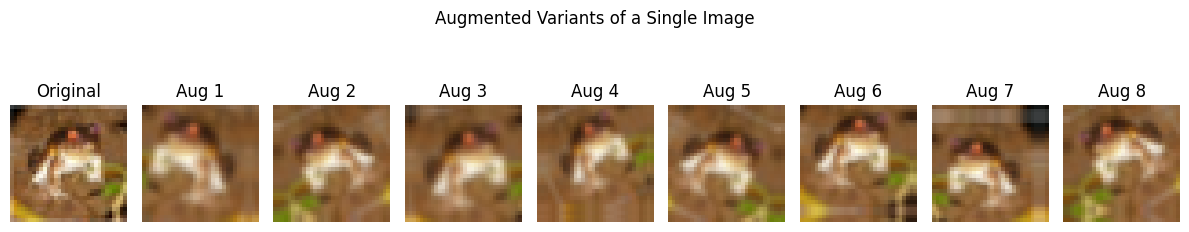

In [19]:
sample_img = x_train[:1]
plt.figure(figsize=(12, 2.5))
plt.subplot(1, 9, 1)
plt.imshow(sample_img[0])
plt.title("Original")
plt.axis("off")
for i in range(2, 10):
    aug = data_augmentation(sample_img, training=True)[0].numpy()
    plt.subplot(1, 9, i)
    plt.imshow(aug)
    plt.title(f"Aug {i-1}")
    plt.axis("off")
plt.suptitle("Augmented Variants of a Single Image", y=1.05)
plt.tight_layout()
plt.show()

## **CNN Model Architecture**

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_1 (BatchNormalization)      │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_2 (Conv2D)                │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3_2 (BatchNormalization)      │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dense (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,57

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

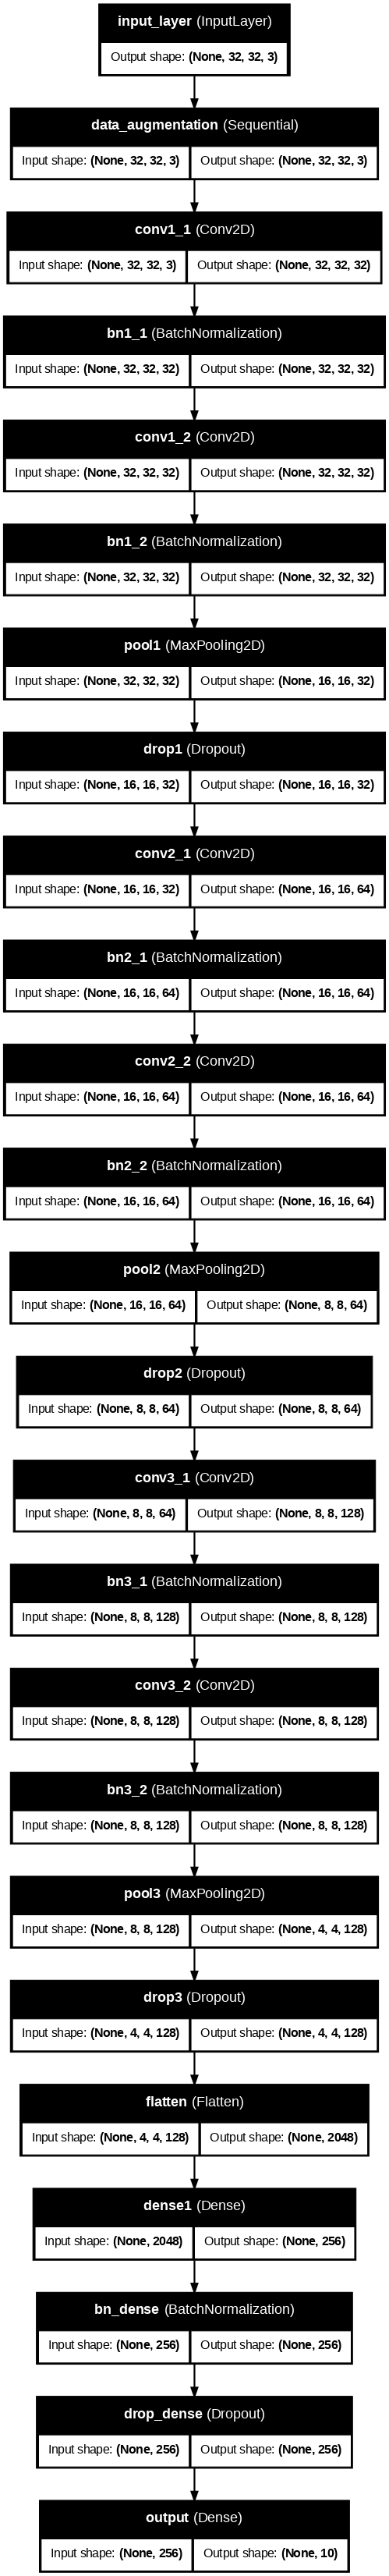

In [20]:
def build_cifar10_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape, name="input_layer")

    # ── Data Augmentation (only active during training) ─────────────────────────
    x = data_augmentation(inputs)

    # ══════════════════════════════════════════════════════════════════════════════
    # CONV BLOCK 1  — Extract low-level features (edges, textures, gradients)
    # ══════════════════════════════════════════════════════════════════════════════
    x = layers.Conv2D(
            filters=32,               # 32 learnable feature detectors
            kernel_size=(3, 3),       # 3×3 receptive field — standard choice
            padding="same",           # keeps spatial size: 32×32 → 32×32
            activation="relu",        # ReLU removes negative activations (non-linearity)
            name="conv1_1"
        )(x)
    x = layers.BatchNormalization(name="bn1_1")(x)
    # BatchNorm: normalizes activations per mini-batch.
    # Stabilizes training, acts as mild regularizer, allows higher LR.

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu", name="conv1_2")(x)
    x = layers.BatchNormalization(name="bn1_2")(x)

    x = layers.MaxPooling2D((2, 2), name="pool1")(x)
    # MaxPool: halves spatial dims (32→16) — reduces compute, adds translation invariance.

    x = layers.Dropout(0.25, name="drop1")(x)
    # Dropout 25%: randomly zeros neurons during training to prevent co-adaptation.

    # ══════════════════════════════════════════════════════════════════════════════
    # CONV BLOCK 2  — Extract mid-level features (shapes, corners, object parts)
    # ══════════════════════════════════════════════════════════════════════════════
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu", name="conv2_1")(x)
    x = layers.BatchNormalization(name="bn2_1")(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu", name="conv2_2")(x)
    x = layers.BatchNormalization(name="bn2_2")(x)

    x = layers.MaxPooling2D((2, 2), name="pool2")(x)
    # Spatial dims: 16×16 → 8×8

    x = layers.Dropout(0.30, name="drop2")(x)

    # ══════════════════════════════════════════════════════════════════════════════
    # CONV BLOCK 3  — Extract high-level semantic features (object identity)
    # ══════════════════════════════════════════════════════════════════════════════
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv3_1")(x)
    x = layers.BatchNormalization(name="bn3_1")(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv3_2")(x)
    x = layers.BatchNormalization(name="bn3_2")(x)

    x = layers.MaxPooling2D((2, 2), name="pool3")(x)
    # Spatial dims: 8×8 → 4×4

    x = layers.Dropout(0.40, name="drop3")(x)

    # ══════════════════════════════════════════════════════════════════════════════
    # CLASSIFIER HEAD
    # ══════════════════════════════════════════════════════════════════════════════
    x = layers.Flatten(name="flatten")(x)
    # Flatten: converts 4×4×128 = 2048 feature maps → 1D vector for Dense layers.

    x = layers.Dense(256, activation="relu", name="dense1")(x)
    # Dense 256: learns non-linear combinations of extracted features.

    x = layers.BatchNormalization(name="bn_dense")(x)
    x = layers.Dropout(0.50, name="drop_dense")(x)
    # 50% dropout before final layer — strongest regularization at the decision point.

    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(x)
    # Softmax: converts raw logits to probability distribution over 10 classes.
    # Sum of all outputs = 1.0 — ideal for multi-class classification.

    model = keras.Model(inputs, outputs, name="CIFAR10_CNN")
    return model


model = build_cifar10_cnn()
model.summary()

# Visual: layer shapes
keras.utils.plot_model(model, to_file="model_architecture.png",
                       show_shapes=True, show_layer_names=True, dpi=80)


| Layer              | Purpose                                 | Key Benefit                                          |
| ------------------ | --------------------------------------- | ---------------------------------------------------- |
| Conv2D             | Learn spatial feature detectors         | Local connectivity + weight sharing                  |
| BatchNormalization | Normalize activations per batch         | Faster convergence, reduced internal covariate shift |
| MaxPooling2D       | Downsample feature maps                 | Reduces parameters, adds translation invariance      |
| Dropout            | Randomly zero neurons during training   | Prevents overfitting                                 |
| Flatten            | Reshape 3D tensor → 1D                  | Bridges conv layers and Dense layers                 |
| Dense(256, relu)   | Learn class-discriminating combinations | Non-linear decision boundary                         |
| Dense(10, softmax) | Output class probabilities              | Multi-class probability distribution                 |

In [21]:
# ── Compile ────────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    # Adam: adaptive LR per parameter. Best default for CNNs.
    loss="categorical_crossentropy",
    # CCE: correct loss for one-hot multi-class targets.
    metrics=["accuracy"]
)

# ── Callbacks ──────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,               # stop if no improvement for 10 epochs
        restore_best_weights=True, # roll back to best weights automatically
        verbose=1
    ),
    ModelCheckpoint(
        filepath="cifar10_cnn_best.keras",
        monitor="val_accuracy",
        save_best_only=True,       # only saves when val_accuracy improves
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,                # halve the LR on plateau
        patience=5,                # wait 5 epochs before reducing
        min_lr=1e-6,
        verbose=1
    )
]

# ── Train ──────────────────────────────────────────────────────────────────────
BATCH_SIZE = 64
EPOCHS     = 80   # EarlyStopping will terminate sooner in practice

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.10,   # 10% of train → 45,000 train / 5,000 val
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete.")


Epoch 1/80


E0000 00:00:1773207485.926406      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CIFAR10_CNN_1/drop1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1773207487.115756    1653 cuda_dnn.cc:529] Loaded cuDNN version 91002


704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2951 - loss: 2.2398
Epoch 1: val_accuracy improved from -inf to 0.43040, saving model to cifar10_cnn_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - accuracy: 0.2952 - loss: 2.2393 - val_accuracy: 0.4304 - val_loss: 1.6080 - learning_rate: 0.0010
Epoch 2/80
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4584 - loss: 1.4969
Epoch 2: val_accuracy improved from 0.43040 to 0.50940, saving model to cifar10_cnn_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4584 - loss: 1.4968 - val_accuracy: 0.5094 - val_loss: 1.4225 - learning_rate: 0.0010
Epoch 3/80
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5206 - loss: 1.3304
Epoch 3: val_accuracy improved from 0.50940 to 0.52760, saving model to cifar10_cnn_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5207 - loss: 1.3303 - val_accuracy: 0.5276 - val_loss: 1.4182 - learning_rate: 0.0010
Epoch 4/80
703/704 ━━━━━━━━━━━━━━━━━━━━

## **Evaluation**

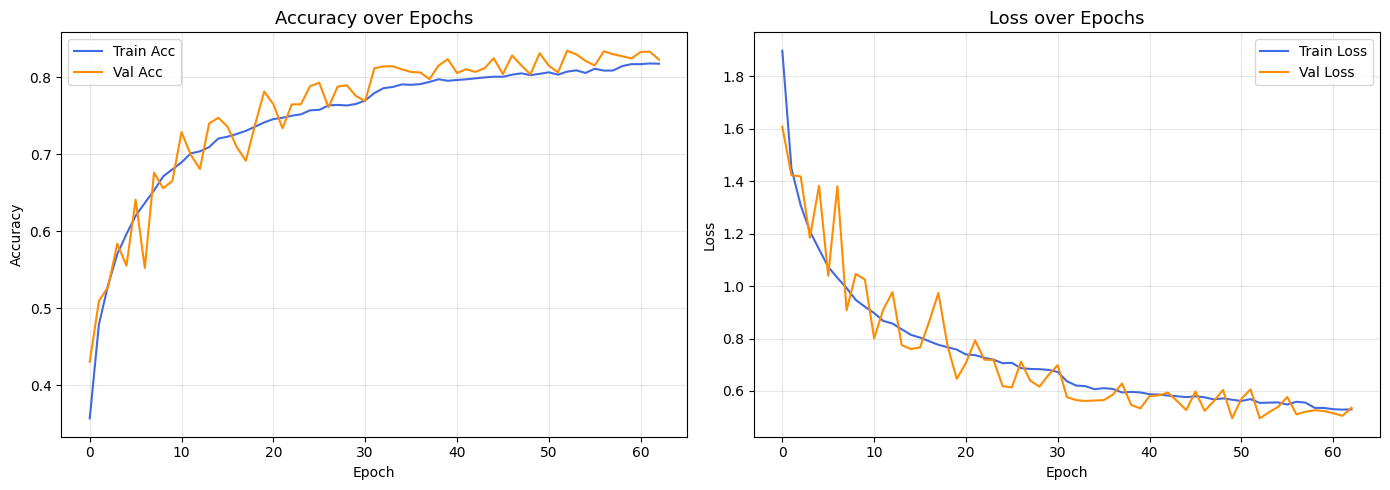

In [22]:
def plot_history(history):
    fig, axes=plt.subplots(1,2, figsize=(14,5))

    axes[0].plot(history.history["accuracy"],label="Train Acc",color="royalblue")
    axes[0].plot(history.history["val_accuracy"],label="Val Acc",color="darkorange")
    axes[0].set_title("Accuracy over Epochs",fontsize=13)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend() 
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"],label="Train Loss" ,color="royalblue")
    axes[1].plot(history.history["val_loss"],label="Val Loss",color="darkorange")
    axes[1].set_title("Loss over Epochs",fontsize=13)
    axes[1].set_xlabel("Epoch") 
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120)
    plt.show()

plot_history(history)

In [23]:
test_loss, test_acc=model.evaluate(x_test, y_test, verbose=0)
print(f"\n📊 Test Accuracy : {test_acc * 100:.2f}%")
print(f"📊 Test Loss     : {test_loss:.4f}")

y_pred_probs=model.predict(x_test, verbose=0)
y_pred=np.argmax(y_pred_probs,axis=1)
y_true=np.argmax(y_test, axis=1)

print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


📊 Test Accuracy : 82.27%
📊 Test Loss     : 0.5291

📋 Classification Report:

              precision    recall  f1-score   support

    airplane       0.86      0.84      0.85      1000
  automobile       0.93      0.93      0.93      1000
        bird       0.82      0.71      0.76      1000
         cat       0.71      0.73      0.72      1000
        deer       0.82      0.76      0.79      1000
         dog       0.88      0.64      0.74      1000
        frog       0.68      0.94      0.79      1000
       horse       0.87      0.85      0.86      1000
        ship       0.91      0.91      0.91      1000
       truck       0.83      0.92      0.88      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



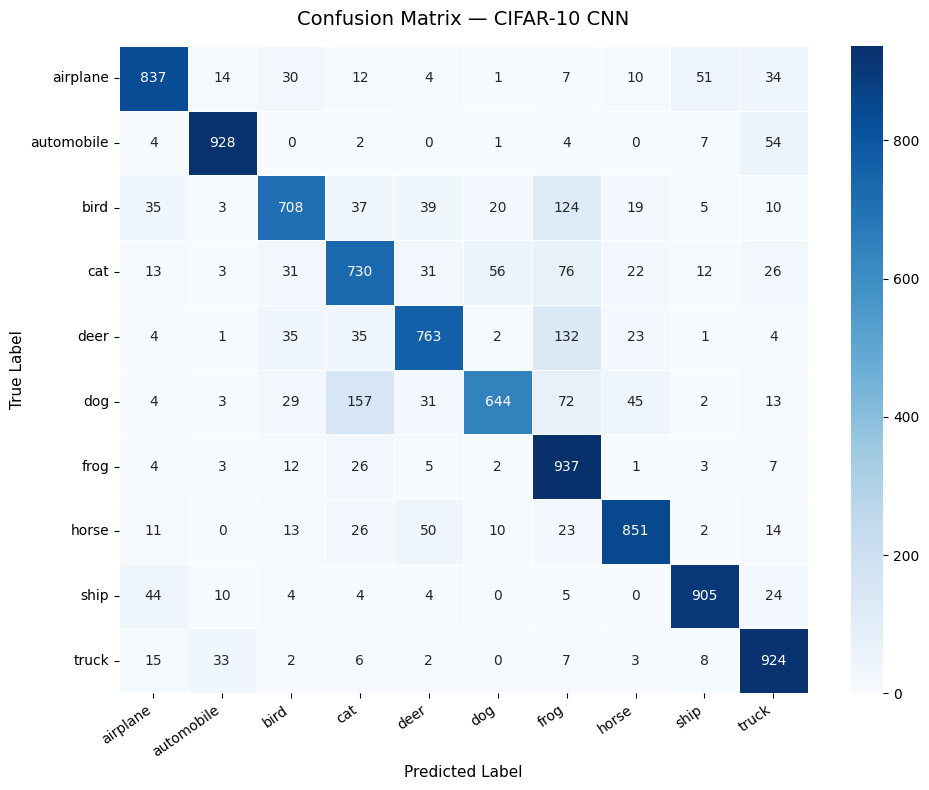

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title("Confusion Matrix — CIFAR-10 CNN", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label",      fontsize=11)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()


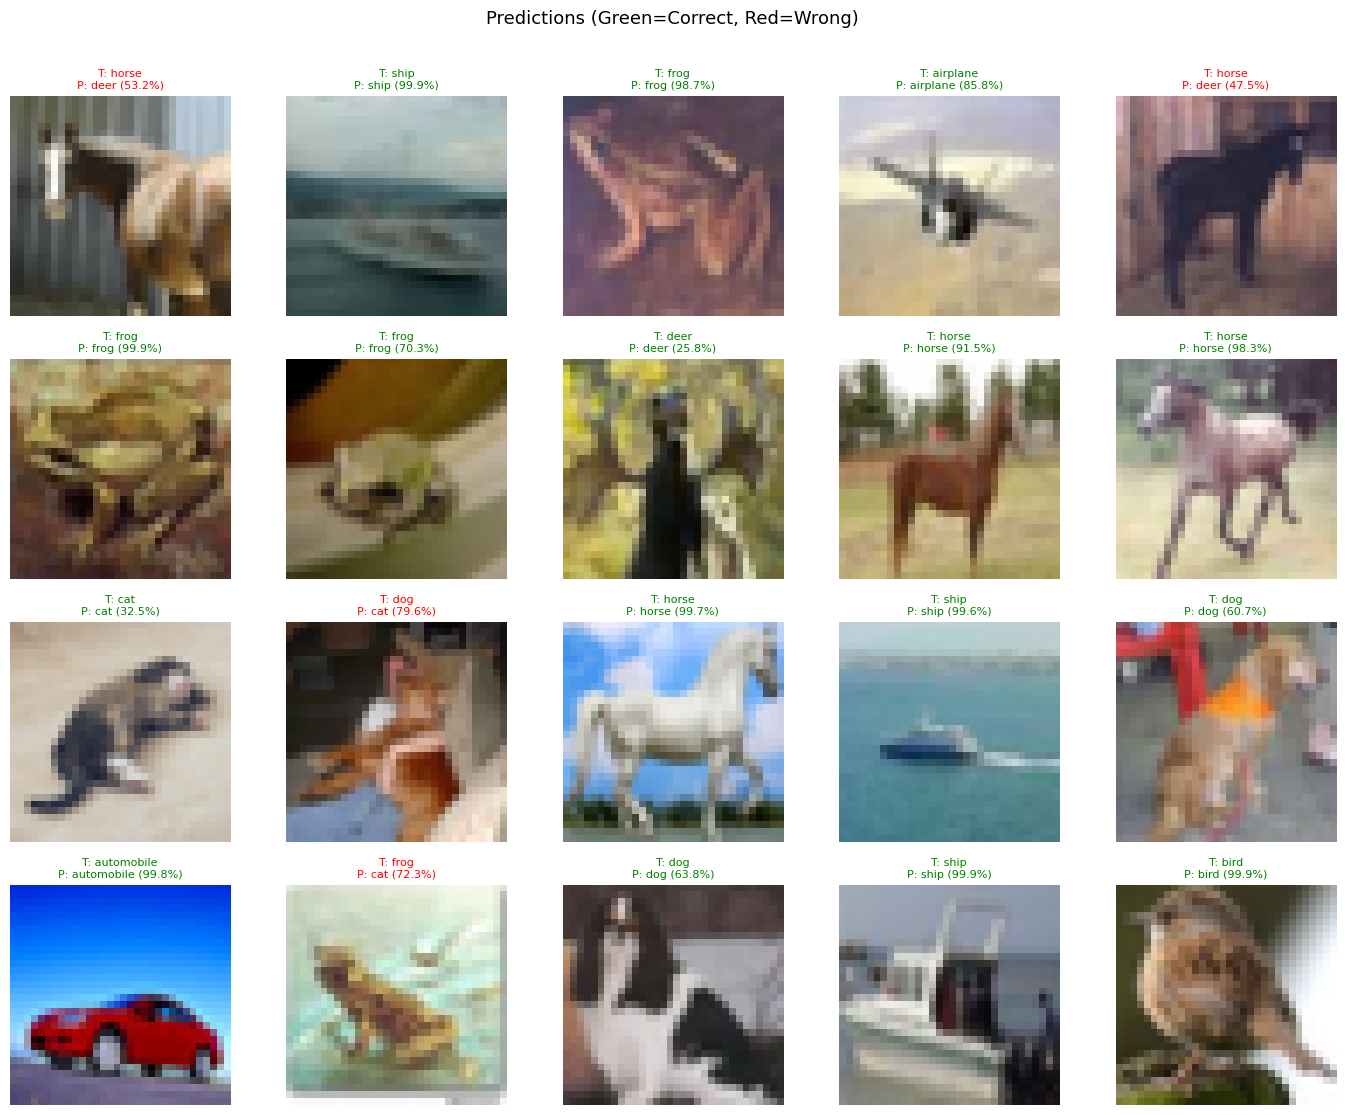

In [25]:
def visualize_predictions(n=20):
    indices = np.random.choice(len(x_test), n, replace=False)
    fig, axes = plt.subplots(4, 5, figsize=(14, 11))
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        img   = x_test[idx]
        true  = CLASS_NAMES[y_true[idx]]
        pred  = CLASS_NAMES[y_pred[idx]]
        conf  = y_pred_probs[idx][y_pred[idx]] * 100
        color = "green" if true == pred else "red"
        axes[i].imshow(img)
        axes[i].set_title(f"T: {true}\nP: {pred} ({conf:.1f}%)",
                          fontsize=8, color=color)
        axes[i].axis("off")
    plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("sample_predictions.png", dpi=120)
    plt.show()

visualize_predictions()


## **Save Model**

In [26]:
model.save("cifar10_cnn.keras")
print("✅ Model saved as: cifar10_cnn.keras")

loaded_model = keras.models.load_model("cifar10_cnn.keras")
reloaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)[1]
print(f"✅ Reloaded model accuracy: {reloaded_acc * 100:.2f}%")


✅ Model saved as: cifar10_cnn.keras
✅ Reloaded model accuracy: 82.27%
